# Plot

In [45]:
import os
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq
from sklearn.manifold import TSNE

mpl.rcParams.update({
    "pdf.fonttype": 42,            # editable text in Adobe Illustrator
    "ps.fonttype": 42,             # editable text in Adobe Illustrator

    "figure.dpi": 200,
    "savefig.dpi": 600,              # very high-res when saving
    "savefig.format": "pdf",         # vector output preferred

    # # Fonts
    "font.family": "serif",
    # "font.serif": ["Times New Roman"],  # IEEE default

    # font size
    "axes.titlesize": 14,      # subplot title
    "axes.labelsize": 14,      # x/y axis labels
    "xtick.labelsize": 12,     # x tick labels
    "ytick.labelsize": 12,     # y tick labels
    "legend.fontsize": 10,     # legend text
    "figure.titlesize": 14,    # fig.suptitle

    # # Axes
    "axes.linewidth": 1.0,
    # Lines
    "lines.linewidth": 1.5,
})

# plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# vae TCN student (distillation only)
DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/soft_contact"
data_dir = DATA_ROOT / "2026-05-19_20-14-31" / "logs"

In [46]:
base_pos_idx = slice(0, 3)
base_quat_idx = slice(3, 7)   # w, x, y, z
base_lin_vel_idx = slice(7, 10)   # x, y, z
base_ang_vel_idx = slice(10, 13)   # roll, pitch, yaw
grf_idx = slice(13, 16)

contact_points_num = 2*2*6
# contact_points_num = 5*5*6

In [ ]:
# data_path = data_dir / "2D_RFT_basalt"
# data_path = data_dir / "2D_RFT_sand"
# data_path = data_dir / "2D_RFT_poppy"

# data_path = data_dir / "3D_RFT_basalt"
# data_path = data_dir / "3D_RFT_sand"
# data_path = data_dir / "3D_RFT_poppy"

terrain = "basalt"
# terrain = "poppy"

data_path = data_dir / f"{terrain}_3d_rft"
# data_path = data_dir / f"{terrain}_2d_rft"


policy_obs_path = (data_path / "obs/obs.pkl").as_posix()
contact_angle_path = (data_path / "contact_angle/contact_angle.pkl").as_posix()
contact_vec_dir_path = (data_path / "contact_vectors/contact_vectors.pkl").as_posix()
contact_point_pos_path = (data_path / "contact_point_pos/contact_point_pos.pkl").as_posix()
contact_point_vel_path = (data_path / "contact_point_vel/contact_point_vel.pkl").as_posix()
contact_point_force_path = (data_path / "contact_point_force/contact_point_force.pkl").as_posix()
root_lin_vel_path = (data_path / "root_lin_vel/root_lin_vel.pkl").as_posix()

with open(policy_obs_path, "rb") as f:
    policy_obs = pickle.load(f)
    policy_obs = np.array(policy_obs).squeeze(0)
    
with open(contact_angle_path, "rb") as f:
    contact_angle = pickle.load(f)
    contact_angle = np.array(contact_angle).squeeze(0)
    
with open(contact_vec_dir_path, "rb") as f:
    contact_vec_dir = pickle.load(f)
    contact_vec_dir = np.array(contact_vec_dir).squeeze(0)
    
with open(contact_point_pos_path, "rb") as f:
    contact_point_pos = pickle.load(f)
    contact_point_pos = np.array(contact_point_pos).squeeze(0)
    
with open(contact_point_vel_path, "rb") as f:
    contact_point_vel = pickle.load(f)
    contact_point_vel = np.array(contact_point_vel).squeeze(0)
    
with open(contact_point_force_path, "rb") as f:
    contact_point_force = pickle.load(f)
    contact_point_force = np.array(contact_point_force).squeeze(0)
    
with open(root_lin_vel_path, "rb") as f:
    root_lin_vel = pickle.load(f)
    # root_lin_vel = np.array(root_lin_vel).squeeze(0).squeeze(2)
    root_lin_vel = np.array(root_lin_vel).squeeze(0)
    
print(f"policy_obs shape: {policy_obs.shape}")
print(f"contact_angle shape: {contact_angle.shape}")
print(f"contact_vec_dir shape: {contact_vec_dir.shape}")
print(f"contact_point_pos shape: {contact_point_pos.shape}")
print(f"contact_point_vel shape: {contact_point_vel.shape}")
print(f"contact_point_force shape: {contact_point_force.shape}")
print(f"root_lin_vel shape: {root_lin_vel.shape}")

data = {}
data["base_pos"] = policy_obs[:, :, base_pos_idx]
data["base_lin_vel"] = policy_obs[:, :, base_lin_vel_idx]
data["base_ang_vel"] = policy_obs[:, :, base_ang_vel_idx]
data["GRF"] = policy_obs[:, :, grf_idx]

data["contact_beta"] = contact_angle[:, :, :contact_points_num]
data["contact_gamma"] = contact_angle[:, :, contact_points_num:2*contact_points_num]
data["contact_psi"] = contact_angle[:, :, 2*contact_points_num:3*contact_points_num]

data["contact_n_dir"] = contact_vec_dir[:, :, :contact_points_num, :]
data["contact_r_dir"] = contact_vec_dir[:, :, contact_points_num:2*contact_points_num, :]
data["contact_t_dir"] = contact_vec_dir[:, :, 2*contact_points_num:3*contact_points_num, :]
data["contact_v_dir"] = contact_vec_dir[:, :, 3*contact_points_num:4*contact_points_num, :]

data["contact_point_pos"] = contact_point_pos
data["contact_point_vel"] = contact_point_vel
data["contact_point_force"] = contact_point_force
data["root_lin_vel"] = root_lin_vel

# manuall compute linear velocity from vi = vb + w x r
contact_point_vel_manual = data["base_lin_vel"][:, :, np.newaxis, :] + np.cross(data["base_ang_vel"][:, :, np.newaxis, :], data["contact_point_pos"] - data["base_pos"][:, :, np.newaxis, :], axis=-1)
data["contact_point_vel_manual"] = contact_point_vel_manual

# frame_dt = 1/50
frame_dt = 1/500
time = np.arange(policy_obs.shape[1]) * frame_dt

policy_obs shape: (1, 1000, 16)
contact_angle shape: (1, 1000, 450)
contact_vec_dir shape: (1, 1000, 600, 3)
contact_point_pos shape: (1, 1000, 150, 3)
contact_point_vel shape: (1, 1000, 150, 3)
contact_point_force shape: (1, 1000, 150, 3)
root_lin_vel shape: (1, 1000, 1, 3)


### Timed data analysis

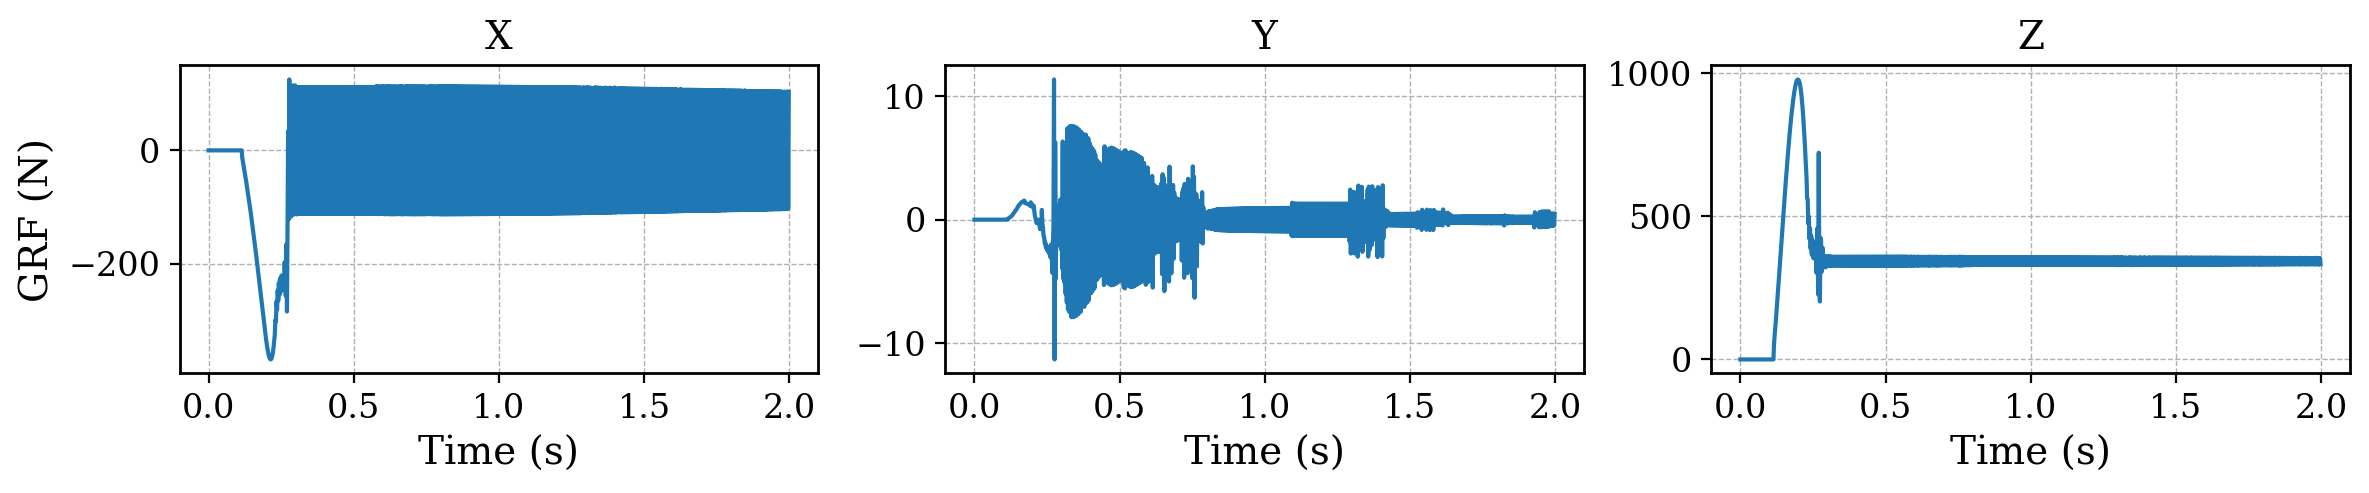

In [53]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharex=True, sharey=False)

grf = data["GRF"][env_id, :, :]

axs[0].plot(time, grf[:, 0])
axs[0].set_xlabel("Time (s)")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title("X")

axs[1].plot(time, grf[:, 1])
axs[1].set_xlabel("Time (s)")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_title("Y")
# axs[1].set_ylim(-0.5, 0.5)

axs[2].plot(time, grf[:, 2])
axs[2].set_xlabel("Time (s)")
axs[2].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[2].set_title("Z")

axs[0].set_ylabel("GRF (N)")
# axs[1].set_ylabel("GRF (N)")
# axs[2].set_ylabel("GRF (N)")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.savefig("grf_plot.pdf")
plt.show()

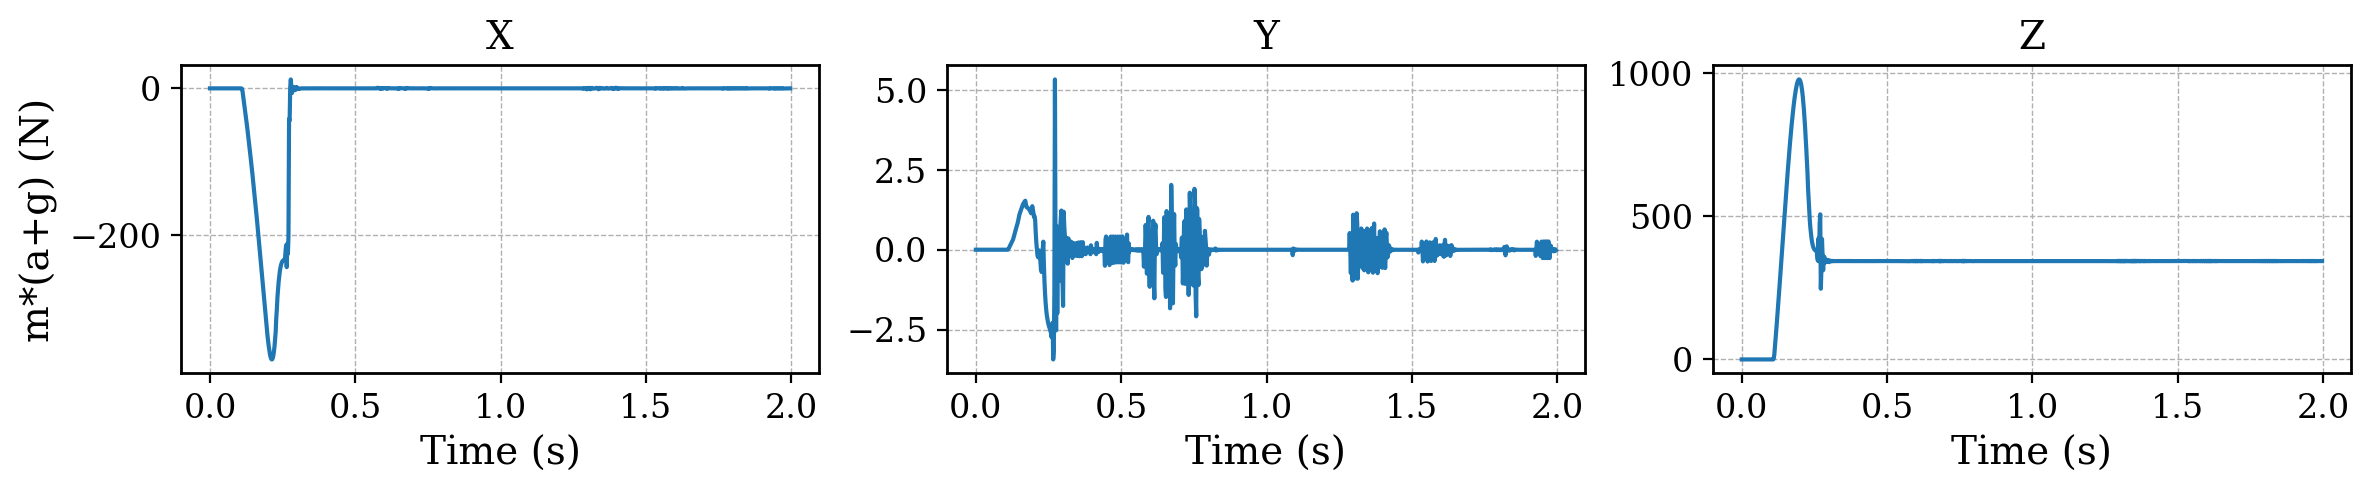

In [54]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharex=True, sharey=False)

time_mask = slice(0, -1)
vel = data["base_lin_vel"][env_id, :, :]
accel = np.gradient(vel, axis=0) / frame_dt

mass = 35.0
force = mass * accel
force[:, 2] += 9.81 * mass   # add gravity compensation

axs[0].plot(time[time_mask], force[time_mask, 0])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("m*(a+g) (N)")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title("X")

axs[1].plot(time[time_mask], force[time_mask, 1])
axs[1].set_xlabel("Time (s)")
# axs[1].set_ylabel("v (m/s)")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_title("Y")

axs[2].plot(time[time_mask], force[time_mask, 2])
axs[2].set_xlabel("Time (s)")
# axs[2].set_ylabel("v (m/s)")
axs[2].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[2].set_title("Z")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

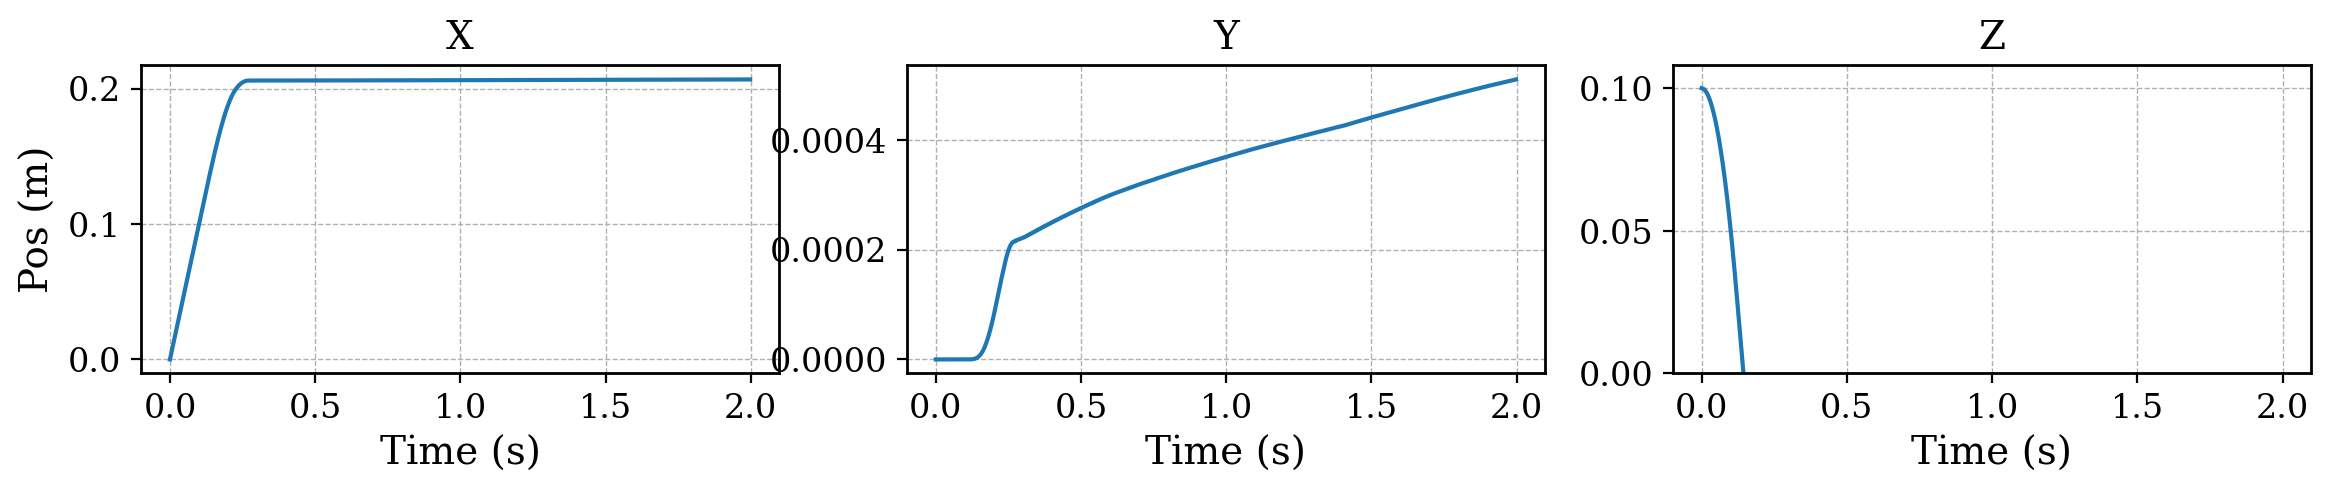

In [56]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharex=True, sharey=False)

vel = data["base_pos"][env_id, :, :]

axs[0].plot(time, vel[:, 0])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Pos (m)")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title("X")

axs[1].plot(time, vel[:, 1])
axs[1].set_xlabel("Time (s)")
# axs[1].set_ylabel("v (m/s)")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_title("Y")

axs[2].plot(time, vel[:, 2])
axs[2].set_xlabel("Time (s)")
# axs[2].set_ylabel("v (m/s)")
axs[2].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[2].set_title("Z")
axs[2].set_ylim(0.0, None)

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

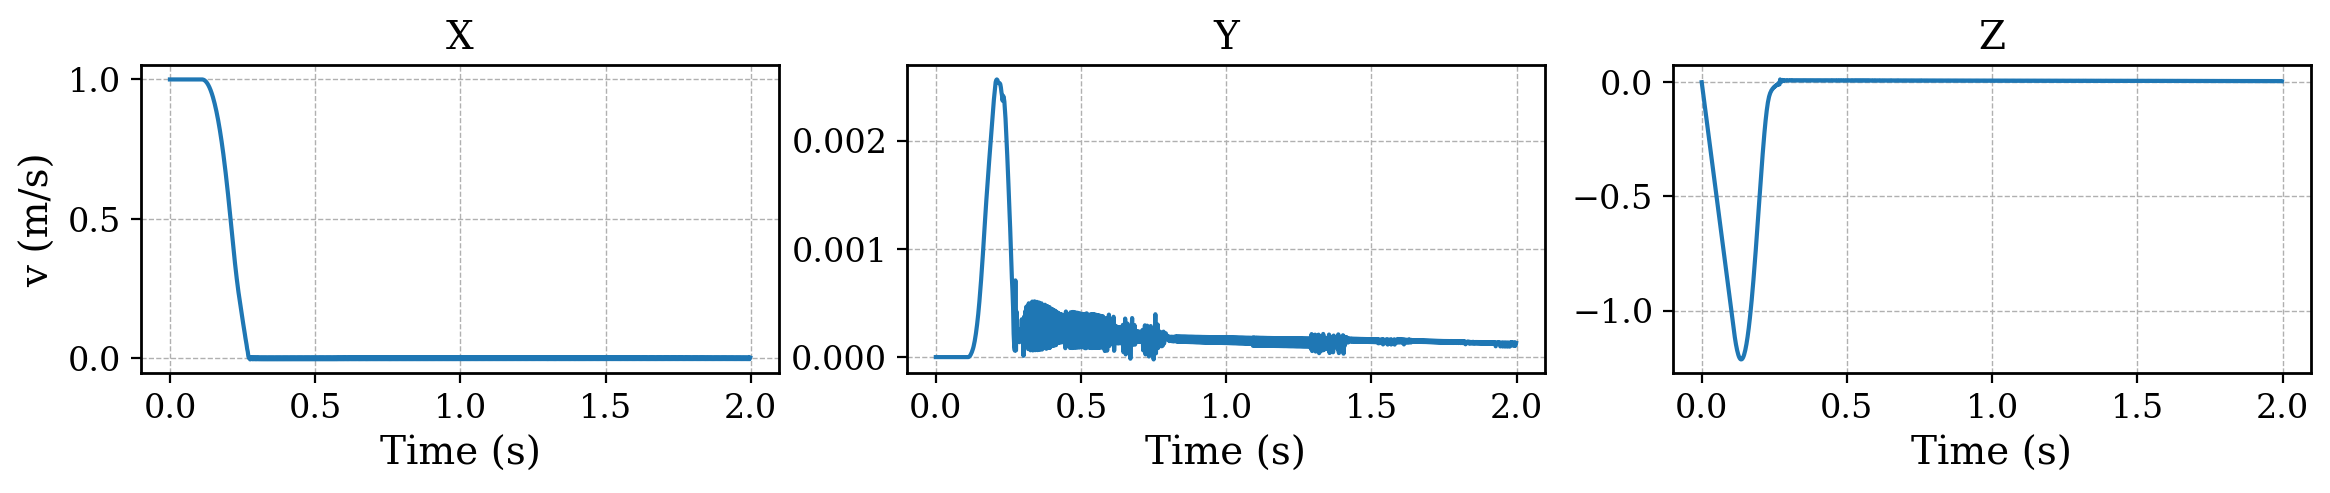

In [57]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharex=True, sharey=False)

vel = data["base_lin_vel"][env_id, :, :]

axs[0].plot(time, vel[:, 0])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("v (m/s)")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title("X")

axs[1].plot(time, vel[:, 1])
axs[1].set_xlabel("Time (s)")
# axs[1].set_ylabel("v (m/s)")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_title("Y")

axs[2].plot(time, vel[:, 2])
axs[2].set_xlabel("Time (s)")
# axs[2].set_ylabel("v (m/s)")
axs[2].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[2].set_title("Z")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

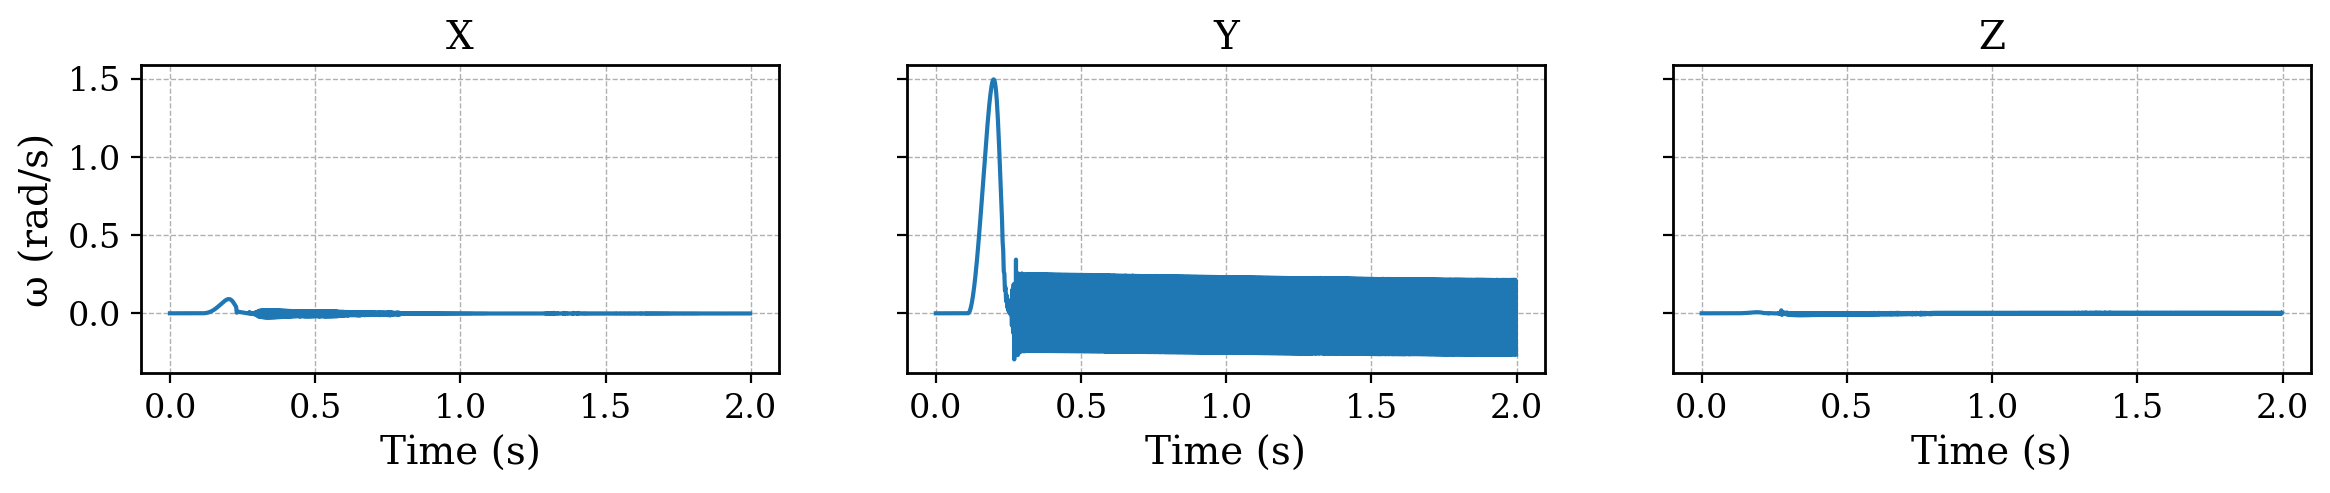

In [58]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(14, 2), sharex=True, sharey=True)

vel = data["base_ang_vel"][env_id, :, :]

axs[0].plot(time, vel[:, 0])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("ω (rad/s)")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title("X")

axs[1].plot(time, vel[:, 1])
axs[1].set_xlabel("Time (s)")
# axs[1].set_ylabel("v (m/s)")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_title("Y")

axs[2].plot(time, vel[:, 2])
axs[2].set_xlabel("Time (s)")
# axs[2].set_ylabel("v (m/s)")
axs[2].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[2].set_title("Z")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

### Contact point level analysis

In [13]:
num_envs = policy_obs.shape[0]
time_length = policy_obs.shape[1]

beta = data["contact_beta"].reshape(num_envs, time_length, 6, -1)
gamma = data["contact_gamma"].reshape(num_envs, time_length, 6, -1)
psi = data["contact_psi"].reshape(num_envs, time_length, 6, -1)

n_vec = data["contact_n_dir"].reshape(num_envs, time_length, 6, -1, 3)
r_vec = data["contact_r_dir"].reshape(num_envs, time_length, 6, -1, 3)
t_vec = data["contact_t_dir"].reshape(num_envs, time_length, 6, -1, 3)
v_vec = data["contact_v_dir"].reshape(num_envs, time_length, 6, -1, 3)

contact_point_pos = data["contact_point_pos"].reshape(num_envs, time_length, 6, -1, 3)
contact_point_vel = data["contact_point_vel"].reshape(num_envs, time_length, 6, -1, 3)

print(beta.shape)
print(gamma.shape)
print(psi.shape)
print(n_vec.shape)
print(r_vec.shape)
print(t_vec.shape)
print(v_vec.shape)
print(contact_point_pos.shape)
print(contact_point_vel.shape)

(1, 100, 6, 4)
(1, 100, 6, 4)
(1, 100, 6, 4)
(1, 100, 6, 4, 3)
(1, 100, 6, 4, 3)
(1, 100, 6, 4, 3)
(1, 100, 6, 4, 3)
(1, 100, 6, 4, 3)
(1, 100, 6, 4, 3)


In [14]:
# print(contact_point_vel.shape)
i = int(0.4/frame_dt)
vis_range = slice(12, 16)

print(data["base_lin_vel"][env_id, i, :])
print(data["root_lin_vel"][env_id, i, :])

# sim data and manual compute should be same
contact_point_vel = data["contact_point_vel"][env_id].reshape(time_length, -1, 3)
contact_point_vel_manual = data["contact_point_vel_manual"][env_id].reshape(time_length, -1, 3)


print("contact point velocity from sim: \n", contact_point_vel[i, vis_range, :])
print("contact point velocity from manual compute: \n", contact_point_vel_manual[i, vis_range, :])


[-9.57961311e-06  2.05357559e-02 -1.05143525e-04]
[[ 0.00029004  0.02025023 -0.00016397]]
contact point velocity from sim: 
 [[-0.01465208  0.02624995  0.04359912]
 [-0.01468859  0.03183405 -0.02277034]
 [ 0.0118512   0.00907823  0.0439149 ]
 [ 0.01181469  0.01466233 -0.02245457]]
contact point velocity from manual compute: 
 [[ 0.01485185  0.03099518 -0.02388019]
 [ 0.01488854  0.02629375  0.04312357]
 [-0.01190555  0.01515837 -0.02356176]
 [-0.01186887  0.01045694  0.043442  ]]


lin vel:
[[-0.01465208  0.02624995  0.04359912]
 [-0.01468859  0.03183405 -0.02277034]
 [ 0.0118512   0.00907823  0.0439149 ]
 [ 0.01181469  0.01466233 -0.02245457]]
vel dir:
[[-0.27666458  0.4956588   0.82325053]
 [-0.35135204  0.7614727  -0.5446681 ]
 [ 0.2555018   0.19571899  0.9467681 ]
 [ 0.40315035  0.50031966 -0.76621264]]


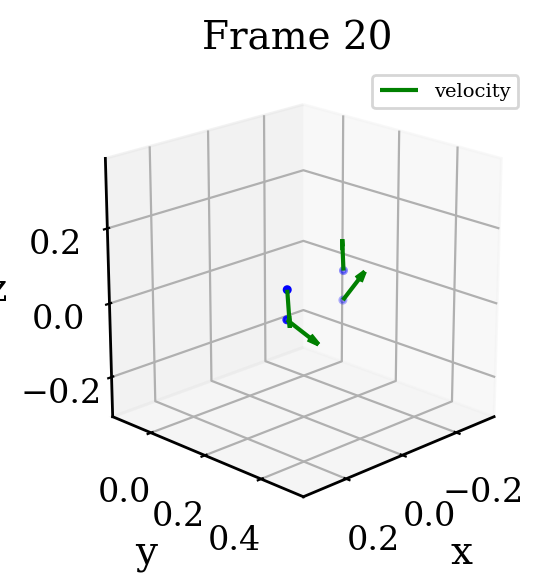

In [16]:
def plot_contact(contact_point_pos, contact_point_vel, contact_normal, contact_velocity, i, arrow_len=0.05):
    """
    contact_point_pos:  (T, N, 3)
    contact_point_vel:  (T, N, 3)
    contact_normal:     (T, N, 3)
    contact_velocity:   (T, N, 3)
    i: time index
    """
    pos = contact_point_pos[i]
    n = contact_normal[i]
    v = contact_velocity[i]
    lin_vel = contact_point_vel[i]

    all_pos = contact_point_pos.reshape(-1, 3)
    center = all_pos.mean(axis=0)
    extent = np.abs(all_pos - center).max() * 1.5

    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_subplot(111, projection='3d')

    # ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c='b', s=5)
    # # ax.quiver(pos[:,0], pos[:,1], pos[:,2], n[:,0], n[:,1], n[:,2],
    # #           length=arrow_len, normalize=True, color='r', label='normal')
    # ax.quiver(pos[:,0], pos[:,1], pos[:,2], v[:,0], v[:,1], v[:,2],
    #           length=arrow_len, normalize=True, color='g', label='velocity')
    # num_vis = 4 * 2
    # vis_range = slice(0, 4)
    # vis_range = slice(4, 8)
    # vis_range = slice(8, 12)
    vis_range = slice(12, 16)
    ax.scatter(pos[vis_range, 0], pos[vis_range, 1], pos[vis_range, 2], c='b', s=5)
    ax.quiver(pos[vis_range,0], pos[vis_range,1], pos[vis_range,2], v[vis_range,0], v[vis_range,1], v[vis_range,2],
                length=arrow_len, normalize=True, color='g', label='velocity')
    print("lin vel:")
    print(lin_vel[vis_range])
    print("vel dir:")
    print(v[vis_range])
    ax.set_xlim(center[0] - extent, center[0] + extent)
    ax.set_ylim(center[1] - extent, center[1] + extent)
    ax.set_zlim(center[2] - extent, center[2] + extent)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(f'Frame {i}')
    ax.legend(loc='upper right', fontsize=7)
    ax.view_init(elev=20, azim=45)
    plt.show()

# Usage:
env_id = 0 
contact_point_pos = data["contact_point_pos"][env_id].reshape(time_length, -1, 3)
contact_point_vel = data["contact_point_vel"][env_id].reshape(time_length, -1, 3)
contact_normal = n_vec[env_id].reshape(time_length, -1, 3)
contact_velocity = v_vec[env_id].reshape(time_length, -1, 3)

i = int(0.4/frame_dt)
# print("contact velocity: \n", contact_velocity[i, :4])
plot_contact(contact_point_pos, contact_point_vel, contact_normal, contact_velocity, i=i, arrow_len=0.1)

vel dir:
[[-0.15452844  0.42493752  0.89193505]
 [-0.6369305  -0.22701962  0.7367346 ]
 [ 0.1545107   0.16591753  0.9739594 ]
 [ 0.37214708 -0.8090945   0.45483014]]
lin vel:
[[-0.00360659  0.00991774  0.02081714]
 [-0.00346747 -0.0012359   0.0040108 ]
 [ 0.00334093  0.00358758  0.02105958]
 [ 0.00348005 -0.00756607  0.00425324]]


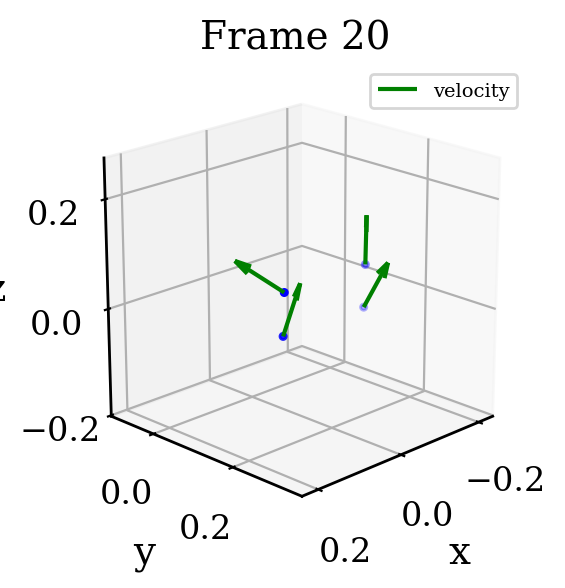

In [93]:
def plot_contact(contact_point_pos, contact_point_vel, contact_normal, contact_velocity, i, arrow_len=0.05):
    """
    contact_point_pos:  (T, N, 3)
    contact_point_vel:  (T, N, 3)
    contact_normal:     (T, N, 3)
    contact_velocity:   (T, N, 3)
    i: time index
    """
    pos = contact_point_pos[i]
    n = contact_normal[i]
    v = contact_velocity[i]
    lin_vel = contact_point_vel[i]

    all_pos = contact_point_pos.reshape(-1, 3)
    center = all_pos.mean(axis=0)
    extent = np.abs(all_pos - center).max() * 1.5

    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_subplot(111, projection='3d')

    # ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c='b', s=5)
    # # ax.quiver(pos[:,0], pos[:,1], pos[:,2], n[:,0], n[:,1], n[:,2],
    # #           length=arrow_len, normalize=True, color='r', label='normal')
    # ax.quiver(pos[:,0], pos[:,1], pos[:,2], v[:,0], v[:,1], v[:,2],
    #           length=arrow_len, normalize=True, color='g', label='velocity')
    # num_vis = 4 * 2
    # vis_range = slice(0, 4)
    # vis_range = slice(4, 8)
    # vis_range = slice(8, 12)
    vis_range = slice(12, 16)
    ax.scatter(pos[vis_range, 0], pos[vis_range, 1], pos[vis_range, 2], c='b', s=5)
    ax.quiver(pos[vis_range,0], pos[vis_range,1], pos[vis_range,2], v[vis_range,0], v[vis_range,1], v[vis_range,2],
                length=arrow_len, normalize=True, color='g', label='velocity')
    print("vel dir:")
    print(v[vis_range])
    print("lin vel:")
    print(lin_vel[vis_range])
    ax.set_xlim(center[0] - extent, center[0] + extent)
    ax.set_ylim(center[1] - extent, center[1] + extent)
    ax.set_zlim(center[2] - extent, center[2] + extent)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(f'Frame {i}')
    ax.legend(loc='upper right', fontsize=7)
    ax.view_init(elev=20, azim=45)
    plt.show()

# Usage:
env_id = 0 
contact_point_pos = data["contact_point_pos"][env_id].reshape(time_length, -1, 3)
contact_point_vel = data["contact_point_vel_manual"][env_id].reshape(time_length, -1, 3)
contact_normal = n_vec[env_id].reshape(time_length, -1, 3)
# contact_velocity = v_vec[env_id].reshape(time_length, -1, 3)
contact_velocity = contact_point_vel / (np.linalg.norm(contact_point_vel, axis=-1, keepdims=True) + 1e-8)

i = int(0.4/frame_dt)
# print("contact velocity: \n", contact_velocity[i, :4])
plot_contact(contact_point_pos, contact_point_vel, contact_normal, contact_velocity, i=i, arrow_len=0.1)

In [10]:
# import matplotlib.animation as mpl_animation

# def animate_contact(contact_point_pos, contact_normal, contact_velocity, 
#                     save_path="/tmp/contact_animation.gif", fps=10, arrow_len=0.05):
#     """
#     contact_point_pos:  (T, N, 3)
#     contact_normal:     (T, N, 3)
#     contact_velocity:   (T, N, 3)
#     """
#     T = contact_point_pos.shape[0]

#     # auto-compute axis limits from all frames
#     all_pos = contact_point_pos.reshape(-1, 3)
#     center = all_pos.mean(axis=0)
#     extent = np.abs(all_pos - center).max() * 1.5

#     fig = plt.figure(figsize=(8, 8))
#     ax = fig.add_subplot(111, projection='3d')

#     def update(idx):
#         ax.cla()
#         pos = contact_point_pos[idx]
#         n = contact_normal[idx]
#         v = contact_velocity[idx]

#         ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c='b', s=20)
#         ax.quiver(pos[:,0], pos[:,1], pos[:,2], n[:,0], n[:,1], n[:,2],
#                   length=arrow_len, normalize=True, color='r', label='normal')
#         ax.quiver(pos[:,0], pos[:,1], pos[:,2], v[:,0], v[:,1], v[:,2],
#                   length=arrow_len, normalize=True, color='g', label='velocity')

#         ax.set_xlim(center[0] - extent, center[0] + extent)
#         ax.set_ylim(center[1] - extent, center[1] + extent)
#         ax.set_zlim(center[2] - extent, center[2] + extent)
#         ax.set_box_aspect([1, 1, 1])
#         ax.set_xlabel('x')
#         ax.set_ylabel('y')
#         ax.set_zlabel('z')
#         ax.set_title(f'Frame {idx}/{T-1}')
#         ax.legend(loc='upper right', fontsize=7)
#         ax.view_init(elev=20, azim=45)

#     ani = mpl_animation.FuncAnimation(fig, update, frames=T, interval=1000//fps)
#     ani.save(save_path, writer='pillow', fps=fps)
#     print(f"Saved to {save_path}")
#     plt.close(fig)


# # Usage:
# env_id = 0 
# contact_point_pos = data["contact_point_pos"][env_id].reshape(time_length, -1, 3)
# contact_normal = n_vec[env_id].reshape(time_length, -1, 3)
# contact_velocity = r_vec[env_id].reshape(time_length, -1, 3)

# n = 30
# animate_contact(contact_point_pos[:n], contact_normal[:n], contact_velocity[:n])

face order: -Z, +Z, -Y, +Y, -X, +X

* beta = angle between n_rt and plate tan vector 
* gamma = angle between r and v vector 
* twist = angle between n_rt and r vector

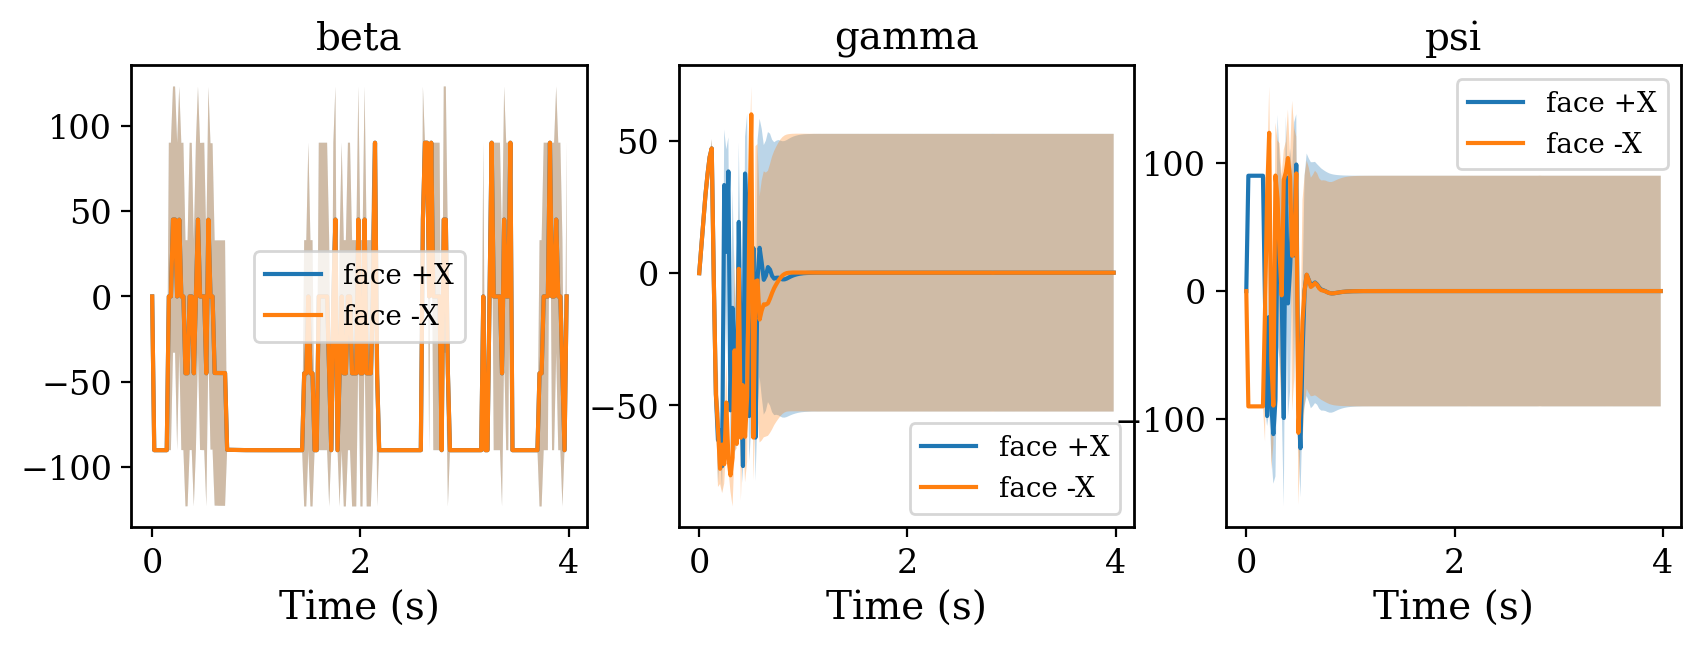

In [11]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=False)

beta_mean = beta[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
beta_std = beta[env_id, :, :, :].std(axis=-1) * (180/np.pi)

gamma_mean = gamma[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
gamma_std = gamma[env_id, :, :, :].std(axis=-1) * (180/np.pi)

psi_mean = psi[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
psi_std = psi[env_id, :, :, :].std(axis=-1) * ( 180/np.pi)

face_name = ["+Z", "-Z", "+Y", "-Y", "+X", "-X"]


for face_id in range(6):
    if face_id in [0, 1, 2, 3]:   # +-X face
    # if face_id in [0, 1, 2, 3, 4]:   # +-X face
    # if face_id in [0, 1, 4, 5]:   # +-Y face
    # if face_id in [2, 3, 4, 5]:   # +-Z face
        continue
    face_id_name = face_name[face_id]
    axs[0].plot(time, beta_mean[:, face_id], label=f"face {face_id_name}")
    axs[0].fill_between(time, beta_mean[:, face_id] - beta_std[:, face_id], beta_mean[:, face_id] + beta_std[:, face_id], alpha=0.3)

    axs[1].plot(time, gamma_mean[:, face_id], label=f"face {face_id_name}")
    axs[1].fill_between(time, gamma_mean[:, face_id] - gamma_std[:, face_id], gamma_mean[:, face_id] + gamma_std[:, face_id], alpha=0.3)

    axs[2].plot(time, psi_mean[:, face_id], label=f"face {face_id_name}")
    axs[2].fill_between(time, psi_mean[:, face_id] - psi_std[:, face_id], psi_mean[:, face_id] + psi_std[:, face_id], alpha=0.3)
    
axs[0].set_xlabel("Time (s)")
# axs[0].set_ylabel("beta (deg)")
axs[0].legend()
axs[0].set_title("beta")

axs[1].set_xlabel("Time (s)")
axs[1].legend()
axs[1].set_title("gamma")
# axs[1].set_ylabel("gamma (deg)")

axs[2].set_xlabel("Time (s)")
axs[2].legend()
axs[2].set_title("psi")
# axs[2].set_ylabel("psi (deg)")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

* beta fluctuates for +-X face 
* gamma flucutates for +-Z and +-Y face 

* Some angle has +- 90deg std -> is it cos/sine singularity??

---

* When projected at vx = 1.0 -> fx converges to non-zero, y converge to 0.0
* When projected at vy = 1.0 -> fx also does not converge to zero \
-> WHY IS THAT?
* Also, when fx is nonzero, but position reaches a equilibrium -> This does not make sense

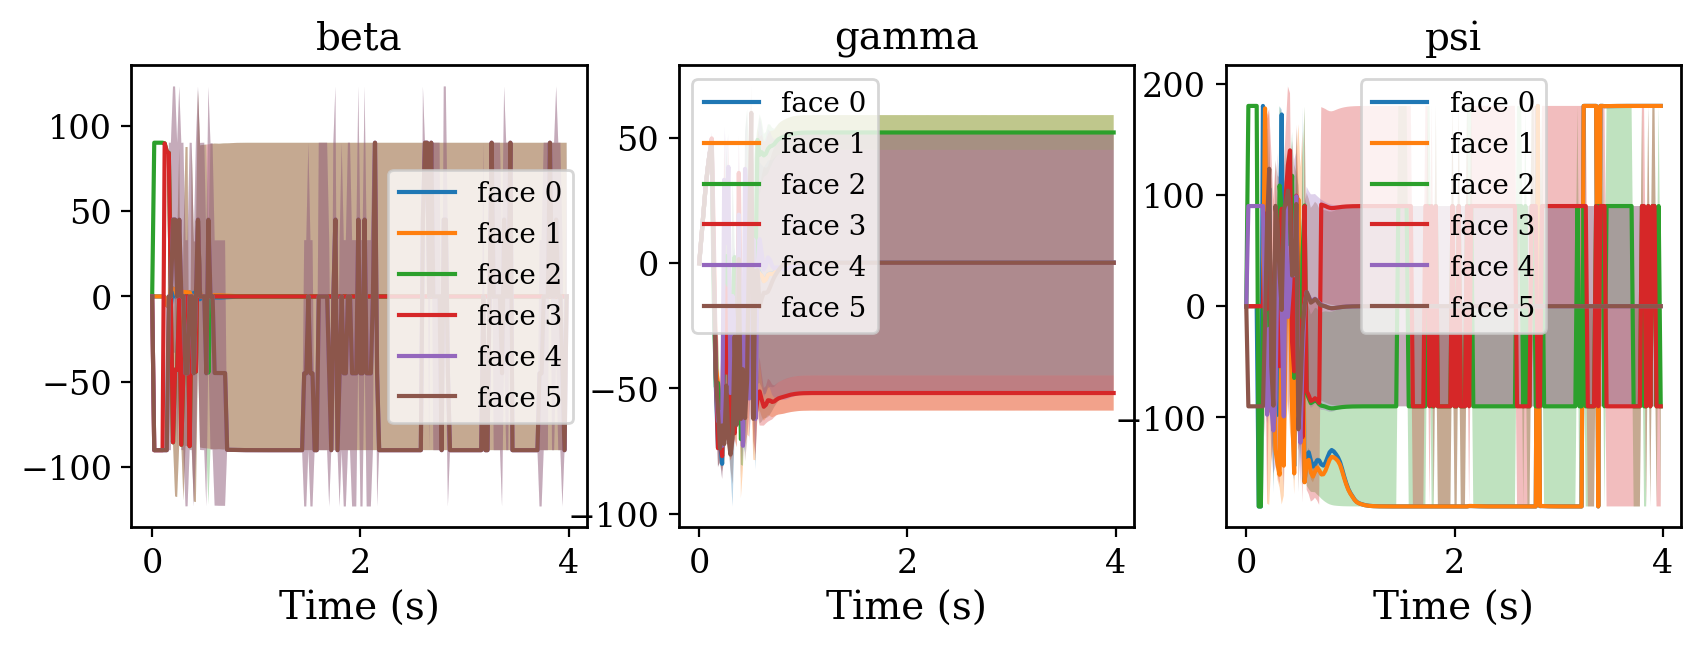

In [68]:
env_id = 0 

fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=False)

beta_mean = beta[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
beta_std = beta[env_id, :, :, :].std(axis=-1) * (180/np.pi)

gamma_mean = gamma[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
gamma_std = gamma[env_id, :, :, :].std(axis=-1) * (180/np.pi)

psi_mean = psi[env_id, :, :, :].mean(axis=-1) * (180/np.pi)
psi_std = psi[env_id, :, :, :].std(axis=-1) * ( 180/np.pi)


for face_id in range(6):
    axs[0].plot(time, beta_mean[:, face_id], label=f"face {face_id}")
    axs[0].fill_between(time, beta_mean[:, face_id] - beta_std[:, face_id], beta_mean[:, face_id] + beta_std[:, face_id], alpha=0.3)

    axs[1].plot(time, gamma_mean[:, face_id], label=f"face {face_id}")
    axs[1].fill_between(time, gamma_mean[:, face_id] - gamma_std[:, face_id], gamma_mean[:, face_id] + gamma_std[:, face_id], alpha=0.3)

    axs[2].plot(time, psi_mean[:, face_id], label=f"face {face_id}")
    axs[2].fill_between(time, psi_mean[:, face_id] - psi_std[:, face_id], psi_mean[:, face_id] + psi_std[:, face_id], alpha=0.3)
    
axs[0].set_xlabel("Time (s)")
# axs[0].set_ylabel("beta (deg)")
axs[0].set_title("beta")
axs[0].legend()

axs[1].set_xlabel("Time (s)")
axs[1].legend()
axs[1].set_title("gamma")
# axs[1].set_ylabel("gamma (deg)")

axs[2].set_xlabel("Time (s)")
axs[2].legend()
axs[2].set_title("psi")
# axs[2].set_ylabel("psi (deg)")

# plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()